In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip -q install ultralytics
!pip -q install kaggle
!pip -q install albumentations
!pip -q install opencv-python
!pip -q install pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.9 MB/s eta 0:00:00


In [3]:
import os
import cv2
import yaml
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm

import albumentations as A

from PIL import Image

In [4]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mennahamdy090","key":"7a8c0f328b97b774acb0d249a0812cec"}'}

In [5]:
!mkdir -p ~/.kaggle

!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API Configured Successfully")

Kaggle API Configured Successfully


In [6]:
!kaggle datasets download \
-d thedatasith/sku110k-annotations \
-p /content

Dataset URL: https://www.kaggle.com/datasets/thedatasith/sku110k-annotations
License(s): Attribution-NonCommercial-ShareAlike 3.0 IGO (CC BY-NC-SA 3.0 IGO)
100% 13.2G/13.2G [02:14<00:00, 105MB/s] 



In [7]:
!unzip -q /content/sku110k-annotations.zip \
-d /content/datasets

In [8]:
PROJECT_ROOT = Path("/content")

DATASET_ROOT = PROJECT_ROOT / "datasets" / "SKU110K_fixed"

print(DATASET_ROOT)

/content/datasets/SKU110K_fixed


In [9]:
assert DATASET_ROOT.exists()

assert (DATASET_ROOT/"images/train").exists()

assert (DATASET_ROOT/"images/val").exists()

assert (DATASET_ROOT/"images/test").exists()

assert (DATASET_ROOT/"labels/train").exists()

assert (DATASET_ROOT/"labels/val").exists()

assert (DATASET_ROOT/"labels/test").exists()

print("Dataset Verified Successfully")

Dataset Verified Successfully


In [10]:
train_images = list((DATASET_ROOT/"images/train").glob("*.jpg"))

val_images = list((DATASET_ROOT/"images/val").glob("*.jpg"))

test_images = list((DATASET_ROOT/"images/test").glob("*.jpg"))

print("Train :",len(train_images))

print("Validation :",len(val_images))

print("Test :",len(test_images))

print("-"*50)

print("Total :",len(train_images)+len(val_images)+len(test_images))

Train : 8185
Validation : 584
Test : 2920
--------------------------------------------------
Total : 11689


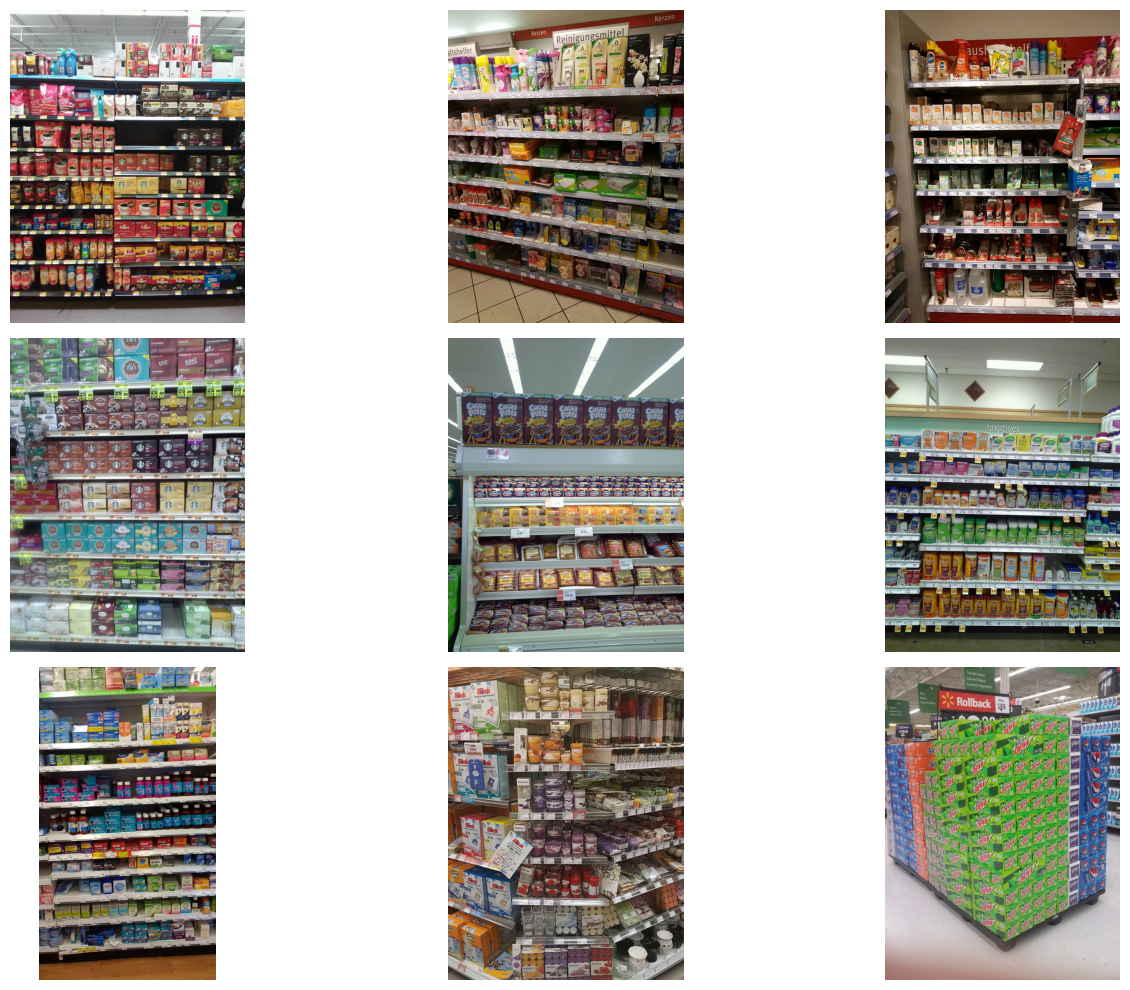

In [11]:
fig = plt.figure(figsize=(15,10))

for i in range(9):

    img_path = random.choice(train_images)

    img = cv2.imread(str(img_path))

    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [12]:
# Analyze Image Sizes


image_info = []

for split in ["train", "val", "test"]:

    image_folder = DATASET_ROOT/"images"/split

    for img_path in tqdm(list(image_folder.glob("*.jpg"))):

        img = cv2.imread(str(img_path))

        h, w = img.shape[:2]

        image_info.append([split, img_path.name, w, h])

image_df = pd.DataFrame(
    image_info,
    columns=["Split","Image","Width","Height"]
)

image_df.head()

100%|██████████| 2920/2920 [02:51<00:00, 17.02it/s]


,Split,Image,Width,Height
0,train,train_1931.jpg,2340,4160
1,train,train_4798.jpg,2448,3264
2,train,train_1297.jpg,2448,3264
3,train,train_7813.jpg,3096,4128
4,train,train_812.jpg,2448,3264


In [13]:
print(image_df.describe())

              Width        Height
count  11689.000000  11689.000000
mean    2435.127470   3214.571392
std      421.284367    673.708158
min      480.000000    640.000000
25%     2336.000000   2560.000000
50%     2448.000000   3264.000000
75%     2448.000000   3264.000000
max     4320.000000   5312.000000


# Product Density

In [14]:
product_count = []

for split in ["train","val","test"]:

    label_folder = DATASET_ROOT/"labels"/split

    for label_file in tqdm(list(label_folder.glob("*.txt"))):

        with open(label_file) as f:

            products = len(f.readlines())

        product_count.append([
            split,
            label_file.stem,
            products
        ])

100%|██████████| 2920/2920 [00:01<00:00, 2677.70it/s]


In [15]:
products_df = pd.DataFrame(
    product_count,
    columns=[
        "Split",
        "Image",
        "Products"
    ]
)

products_df.head()

,Split,Image,Products
0,train,train_5302,116
1,train,train_6870,163
2,train,train_64,155
3,train,train_8198,112
4,train,train_3508,132


In [16]:
products_df.describe()

,Products
count,11689.000000
mean,147.415091
std,43.494457
min,1.000000
25%,123.000000
50%,138.000000
75%,162.000000
max,718.000000


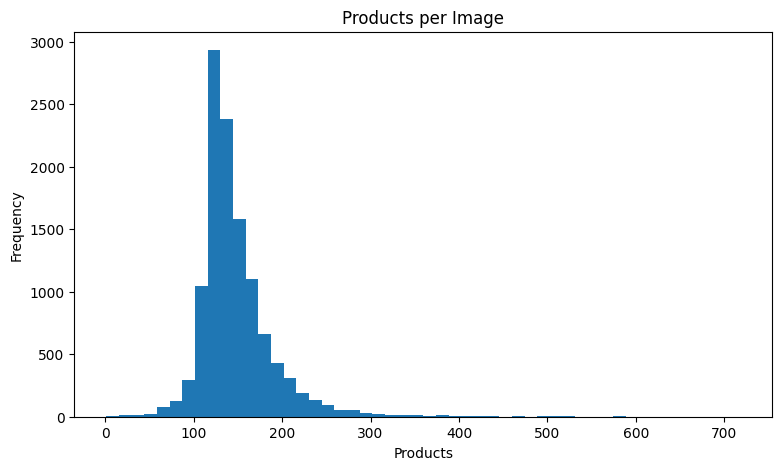

In [17]:
plt.figure(figsize=(9,5))

plt.hist(products_df["Products"], bins=50)

plt.title("Products per Image")

plt.xlabel("Products")

plt.ylabel("Frequency")

plt.show()

# Brightness Analysis

In [18]:
brightness = []

for img_path in tqdm(random.sample(train_images,500)):

    img = cv2.imread(str(img_path))

    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

    brightness.append(gray.mean())

100%|██████████| 500/500 [00:35<00:00, 14.20it/s]


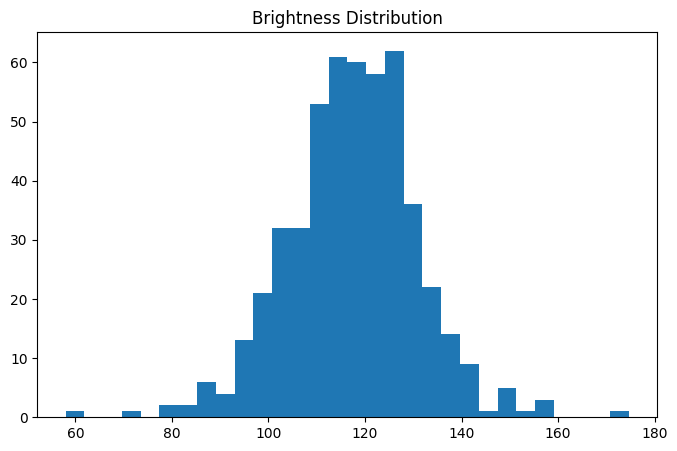

In [19]:
plt.figure(figsize=(8,5))

plt.hist(brightness,bins=30)

plt.title("Brightness Distribution")

plt.show()

# Blur Detection

In [20]:
blur = []

for img_path in tqdm(random.sample(train_images,500)):

    img = cv2.imread(str(img_path))

    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

    score = cv2.Laplacian(
        gray,
        cv2.CV_64F
    ).var()

    blur.append(score)

100%|██████████| 500/500 [01:08<00:00,  7.31it/s]


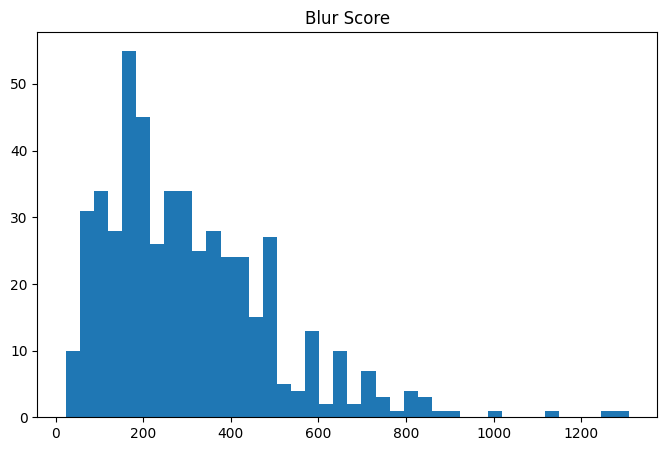

In [21]:
plt.figure(figsize=(8,5))

plt.hist(blur,bins=40)

plt.title("Blur Score")

plt.show()

# Contrast Analysis

In [22]:
contrast = []

for img_path in tqdm(random.sample(train_images,500)):

    img = cv2.imread(str(img_path))

    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

    contrast.append(gray.std())

100%|██████████| 500/500 [00:53<00:00,  9.39it/s]


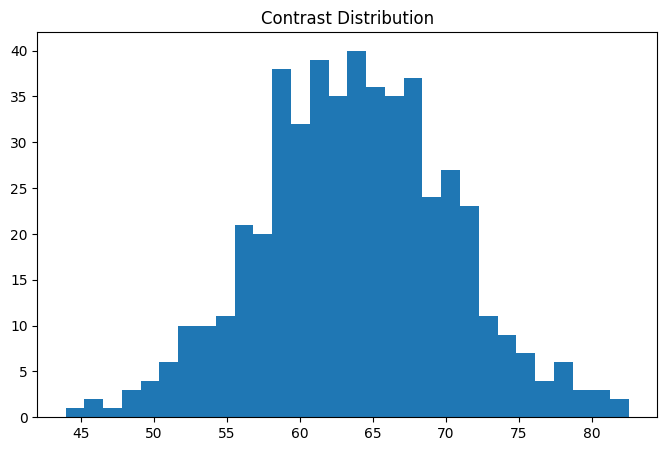

In [23]:
plt.figure(figsize=(8,5))

plt.hist(contrast,bins=30)

plt.title("Contrast Distribution")

plt.show()

# Outlier Detection

In [24]:
high_density = products_df.sort_values(
    "Products",
    ascending=False
)

high_density.head(10)

,Split,Image,Products
8719,val,val_9,718
8247,val,val_456,599
8373,val,val_57,582
2326,train,train_2619,576
5082,train,train_7099,566
10048,test,test_129,533
5140,train,train_7389,530
6810,train,train_7447,520
8506,val,val_475,514
2417,train,train_4221,510


In [25]:
low_density = products_df.sort_values(
    "Products"
)

low_density.head(10)

,Split,Image,Products
1134,train,train_3029,1
3477,train,train_6566,6
7544,train,train_3622,11
513,train,train_2555,16
1556,train,train_6216,18
2239,train,train_7880,19
10702,test,test_974,20
9323,test,test_1397,20
407,train,train_6477,23
4485,train,train_6107,24


# Data Augmentation

In [26]:
# Data Augmentation Pipeline

transform = A.Compose(

    [

        A.HorizontalFlip(p=0.5),

        A.RandomBrightnessContrast(
            brightness_limit=0.2,
            contrast_limit=0.2,
            p=0.5
        ),

        A.HueSaturationValue(
            hue_shift_limit=10,
            sat_shift_limit=20,
            val_shift_limit=20,
            p=0.5
        ),

        A.GaussianBlur(
            blur_limit=3,
            p=0.2
        ),

        A.CLAHE(
            clip_limit=4,
            p=0.3
        )

    ]

)

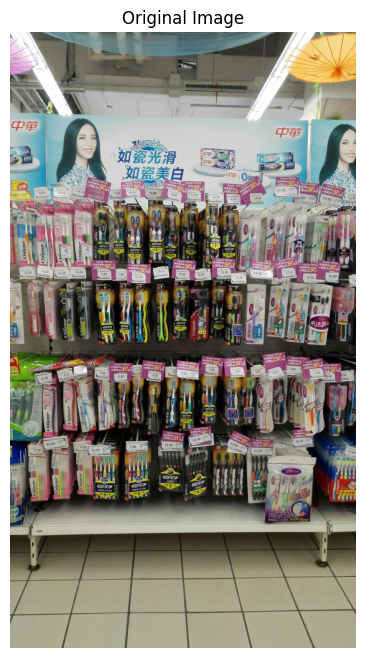

In [27]:
sample_image = random.choice(train_images)

image = cv2.imread(str(sample_image))

image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(8,8))

plt.imshow(image)

plt.title("Original Image")

plt.axis("off")

plt.show()

In [28]:
augmented = transform(image=image)

augmented_image = augmented["image"]

# Compare Images

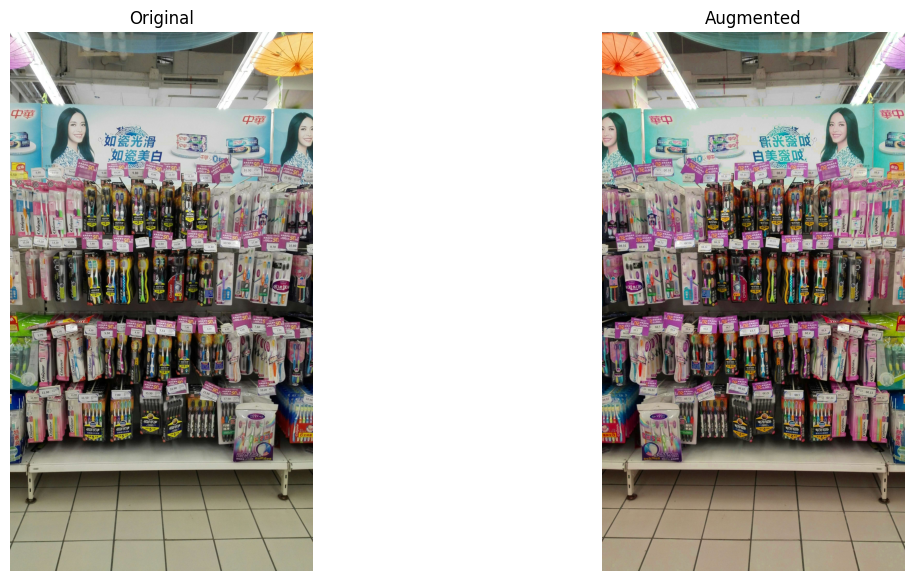

In [29]:
plt.figure(figsize=(14,7))

plt.subplot(1,2,1)

plt.imshow(image)

plt.title("Original")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(augmented_image)

plt.title("Augmented")

plt.axis("off")

plt.show()

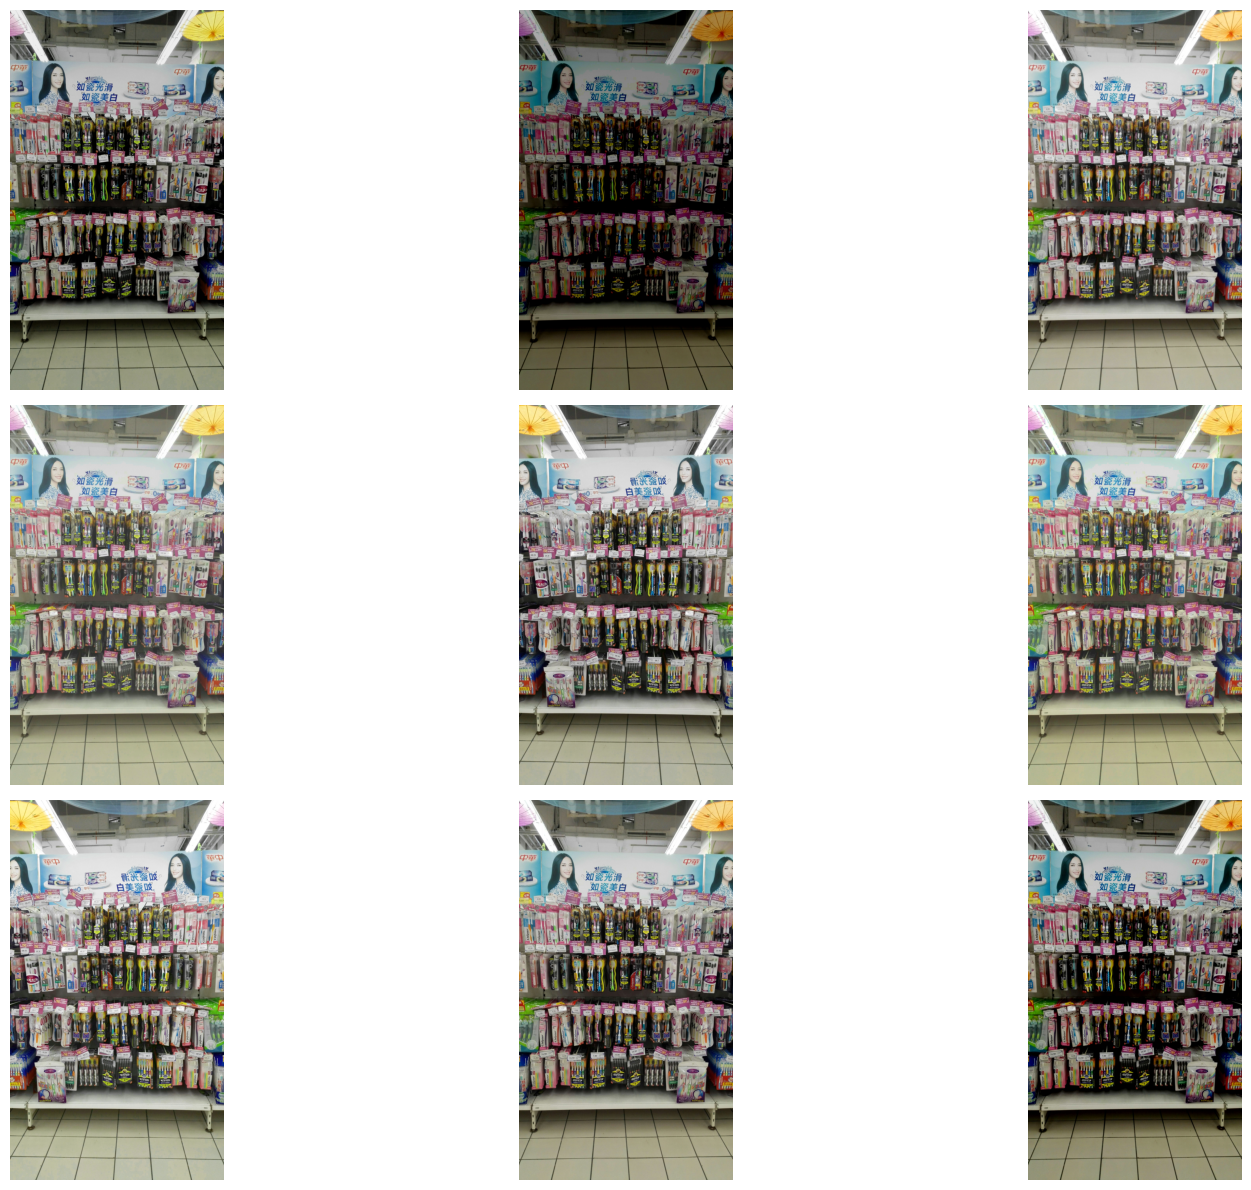

In [30]:
#Multiple Augmentations

plt.figure(figsize=(18,12))

for i in range(9):

    aug = transform(image=image)

    plt.subplot(3,3,i+1)

    plt.imshow(aug["image"])

    plt.axis("off")

plt.tight_layout()

plt.show()

In [31]:
SAVE_PATH = "/content/Augmented_Samples"

os.makedirs(SAVE_PATH, exist_ok=True)

for i in range(10):

    aug = transform(image=image)

    save_name = os.path.join(
        SAVE_PATH,
        f"augmented_{i}.jpg"
    )

    cv2.imwrite(
        save_name,
        cv2.cvtColor(
            aug["image"],
            cv2.COLOR_RGB2BGR
        )
    )

print("Augmented Images Saved")

Augmented Images Saved


# Visual Summary

In [32]:
summary = pd.DataFrame({

    "Metric":[

        "Training Images",

        "Validation Images",

        "Testing Images",

        "Average Products",

        "Maximum Products",

        "Minimum Products"

    ],

    "Value":[

        len(train_images),

        len(val_images),

        len(test_images),

        round(products_df["Products"].mean(),2),

        products_df["Products"].max(),

        products_df["Products"].min()

    ]

})

summary

,Metric,Value
0,Training Images,8185.00
1,Validation Images,584.00
2,Testing Images,2920.00
3,Average Products,147.42
4,Maximum Products,718.00
5,Minimum Products,1.00


In [34]:

print("Notebook 03 Completed Successfully")

print(f"Training Images : {len(train_images)}")

print(f"Validation Images : {len(val_images)}")

print(f"Testing Images : {len(test_images)}")

print(f"Average Products : {products_df['Products'].mean():.2f}")

print(f"Maximum Products : {products_df['Products'].max()}")

print(f"Minimum Products : {products_df['Products'].min()}")



Notebook 03 Completed Successfully
Training Images : 8185
Validation Images : 584
Testing Images : 2920
Average Products : 147.42
Maximum Products : 718
Minimum Products : 1
